## Imports

In [1]:
import os
import re
import random
import cv2
import itertools

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.datasets.folder import make_dataset
from torch.utils.data import DataLoader
import kagglehub

from torchvision.models.video import s3d, S3D_Weights

import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from torchmetrics.classification import MulticlassAccuracy, MulticlassConfusionMatrix
from sklearn.metrics import classification_report

import json
from datetime import datetime

In [2]:
# NOTE: %pip install "numpy<2.0.0,>=1.23.5" "opencv-python<4.10.0"

## Setting Seed Function

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    print(f"Seed set to: {seed}")

## Data downloading

In [4]:
def download_data():
    # Check if the dataset already exists locally in the current directory
    local_path = "./kth_dataset"
    
    if os.path.exists(local_path) and os.path.isdir(local_path):
        dataset_path = local_path
        print(f"Using local dataset found at: {dataset_path}")
    else:
        print("Local dataset not found. Downloading from Kaggle to safe cache...")
        
        # Define safe download path for the restricted server
        safe_cache_dir = "/cephyr/users/domingos/Alvis/data_cache"
        os.makedirs(safe_cache_dir, exist_ok=True)
        os.environ["KAGGLEHUB_CACHE_DIR"] = safe_cache_dir
        
        # Download the dataset
        dataset_path = kagglehub.dataset_download("vafaeii/kth-action-recognition-dataset")
        print("Path to downloaded dataset files:", dataset_path)

    return dataset_path

## Data Visualization

In [5]:
def visualize_data(dataset_path):
    # Create a Matplotlib figure
    plt.figure(figsize=(30, 30))
    
    # Get names of all classes by filtering for directories (ignoring '00sequences.txt' and any other files)   
    all_classes_names = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
 
    # Generate a random sample of images each time the cell runs
    random_range = random.choices(range(len(all_classes_names)), k=20)
    
    # Iterating through all the random samples
    for counter, random_index in enumerate(random_range, 1):
    
        # Getting Class Name using Random Index
        selected_class_Name = all_classes_names[random_index]
    
        # Getting a list of all the video files present in a Class Directory
        class_folder_path = os.path.join(dataset_path, selected_class_Name)
        video_files_names_list = os.listdir(class_folder_path)

        # Randomly selecting a video file
        selected_video_file_name = random.choice(video_files_names_list)
    
        # Reading the Video File Using the Video Capture
        video_path = os.path.join(dataset_path, selected_class_Name, selected_video_file_name)
        video_reader = cv2.VideoCapture(video_path, cv2.CAP_FFMPEG)
        
        # Reading The First Frame of the Video File
        success, bgr_frame = video_reader.read()
    
        # Closing the VideoCapture object and releasing all resources.
        video_reader.release()
    
        # If a video fails to load, skip it so the script doesn't crash
        if not success or bgr_frame is None:
            print(f"Warning: Could not read video {selected_video_file_name}")
            continue    

        # Converting the BGR Frame to RGB Frame
        rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)
    
        # Adding The Class Name Text on top of the Video Frame.
        cv2.putText(rgb_frame, selected_class_Name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 200, 0), 1)
        
        # Assigning the Frame to a specific position of a subplot
        plt.subplot(5, 4, counter)
        plt.imshow(rgb_frame)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

## Data Partiotoning & Splitting

In [6]:
def partition_kth_dataset(orig_dir, target_dir="./kth_split", test_split=0.2, val_split=0.2, seed=0):
    """
    Reads 00sequences.txt, extracts active frame clips, and organizes 
    them into train/validation/test folders based on randomly selecting subject IDs.
    
    Parameters:
    - orig_dir: Path to original KTH dataset
    - target_dir: Where to save the partitioned chunks
    - test_split: Percentage of total subjects reserved for testing (default 0.2 = 20%)
    - val_split: Percentage of the *remaining* subjects reserved for validation (default 0.2 = 20%)
    - seed: Random seed for reproducibility
    """
    # Check if already partitioned
    if os.path.exists(target_dir) and os.path.exists(os.path.join(target_dir, "train")):
        print(f"Dataset already partitioned at '{target_dir}'. Skipping partitioning process.")
        print("Note: If you want to re-roll the random splits, you must delete the folder first.")
        return target_dir
    
    # Randomly Split the 25 Subjects
    random.seed(seed)
    
    # Generate list of subjects ['01', '02', ... '25']
    all_subjects = [f"{i:02d}" for i in range(1, 26)]
    random.shuffle(all_subjects)

    # Calculate partition sizes
    num_total = len(all_subjects)
    num_test = int(num_total * test_split)            # 20% of 25 = 5 subjects
    num_train_val = num_total - num_test              # Remaining 20 subjects
    num_val = int(num_train_val * val_split)          # 20% of 20 = 4 subjects
    
    # Assign subjects to partitions
    test_p = all_subjects[:num_test]
    val_p = all_subjects[num_test : num_test + num_val]
    train_p = all_subjects[num_test + num_val :]

    print(f"Partitioning dataset into {target_dir}...")
    print(f"Subject Splits -> Train: {len(train_p)}, Val: {len(val_p)}, Test: {len(test_p)}")
    
    os.makedirs(target_dir, exist_ok=True)
    
    # Save the exact split logic to a file
    with open(os.path.join(target_dir, "split_records.json"), "w") as f:
        json.dump({"train": train_p, "validation": val_p, "test": test_p}, f, indent=4)

    seq_file = os.path.join(orig_dir, "00sequences.txt")
    if not os.path.exists(seq_file):
        print(f"Error: Could not find 00sequences.txt in {orig_dir}!")
        return orig_dir

    # 2. Parse the sequence file
    with open(seq_file, 'r') as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        if not line or "frames" not in line or "*missing*" in line:
            continue

        # Parse line: person01_boxing_d1  frames  1-95, 96-185, ...
        parts = line.split()
        vid_name = parts[0]

        # Extract frame ranges using regex to grab numbers securely
        ranges_str = " ".join(parts[2:])
        ranges = re.findall(r'(\d+)-(\d+)', ranges_str)

        # Determine Class and Split
        person_id = vid_name.split('_')[0].replace('person', '')
        action = vid_name.split('_')[1]

        # Map to the dynamically generated random splits
        if person_id in train_p: split = 'train'
        elif person_id in val_p: split = 'validation'
        elif person_id in test_p: split = 'test'
        else: continue

        # Locate original video
        orig_vid_path = os.path.join(orig_dir, action, f"{vid_name}_uncomp.avi")
        if not os.path.exists(orig_vid_path):
            continue 

        # Prepare target directory (e.g., ./kth_split/train/boxing)
        out_dir = os.path.join(target_dir, split, action)
        os.makedirs(out_dir, exist_ok=True)

        # Read and Split Video
        cap = cv2.VideoCapture(orig_vid_path)
        fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fourcc = cv2.VideoWriter_fourcc(*'XVID')

        for i, (start_f, end_f) in enumerate(ranges):
            start_f, end_f = int(start_f), int(end_f)
            out_path = os.path.join(out_dir, f"{vid_name}_chunk{i}.avi")

            # Skip if file was already created in a previous notebook run
            if os.path.exists(out_path): 
                continue

            out = cv2.VideoWriter(out_path, fourcc, fps, (w, h))

            # Seek to start frame and read until end frame
            cap.set(cv2.CAP_PROP_POS_FRAMES, start_f - 1)
            for _ in range(start_f, end_f + 1):
                ret, frame = cap.read()
                if not ret: break
                out.write(frame)

            out.release()

        cap.release()

    print("Partitioning complete!")
    return target_dir

## Helper Functions

In [7]:
def _find_classes(dir):
    # Only iterate over directories to ignore files like '00sequences.txt'
    classes = [d.name for d in os.scandir(dir) if d.is_dir()]
    classes.sort()
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

def get_samples(root, extensions=(".mp4", ".avi")):
    _, class_to_idx = _find_classes(root)
    return make_dataset(root, class_to_idx, extensions=extensions)

## Iterable Dataset Definition

In [8]:
class KTHVideoDataset(torch.utils.data.IterableDataset):
    def __init__(self, root, epoch_size=None, transform=None, clip_len=32):
        super(KTHVideoDataset, self).__init__()
        self.samples = get_samples(root)
        
        if epoch_size is None:
            epoch_size = len(self.samples)
        self.epoch_size = epoch_size
        
        self.clip_len = clip_len
        self.transform = transform

    def __iter__(self):
        for _ in range(self.epoch_size):
            path, target = random.choice(self.samples)
            
            try:
                # Open the video using OpenCV
                cap = cv2.VideoCapture(path)
                if not cap.isOpened():
                    continue
                
                # Get total frames to calculate random start
                total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                
                # If video is shorter than our clip length, skip it
                if total_frames < self.clip_len:
                    cap.release()
                    continue
                
                # Seek to a random start frame
                start_frame = random.randint(0, total_frames - self.clip_len)
                cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
                
                video_frames = []
                
                # Read the exact number of frames we need
                for _ in range(self.clip_len):
                    ret, frame = cap.read()
                    if not ret:
                        break
                    
                    # OpenCV loads in BGR format, we need RGB
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    
                    # Convert numpy array (H, W, C) to PyTorch tensor (C, H, W)
                    frame_tensor = torch.from_numpy(frame).permute(2, 0, 1)
                    video_frames.append(frame_tensor)
                    
                cap.release() # Always release the video object
                
                # If for some reason we didn't get enough frames, skip
                if len(video_frames) < self.clip_len:
                    continue
                    
                # Stack to (T, C, H, W) and force the tensor to float and scale it to [0.0, 1.0]
                video = torch.stack(video_frames, 0).float() / 255.0
                
                # Apply S3D transforms
                if self.transform:
                    video = self.transform(video)
                    
                yield video, target
                
            except Exception as e:
                # If a specific AVI file is corrupted, silently skip and grab the next
                continue

## Model Setup


In [9]:
def setup_model():
    # Setup Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Initialize Model & Transforms
    weights = S3D_Weights.KINETICS400_V1
    model = s3d(weights=weights)

    # Transfer Learning Modification
    num_classes = 6 
    in_channels = model.classifier[1].in_channels
    model.classifier[1] = nn.Conv3d(
        in_channels=in_channels, 
        out_channels=num_classes, 
        kernel_size=1, stride=1, padding=0
    )
    model = model.to(device)

    return model, device


## Training Model Function

In [10]:
def train_model(model, dataloaders, device, class_names, num_epochs=30, learning_rate=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Initialize TorchMetrics for accuracy tracking
    num_classes = len(class_names)
    acc_metric = MulticlassAccuracy(num_classes=num_classes, average='micro').to(device)

    # Dictionary to store metrics for plotting
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print("Starting Training Loop...")
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        print("-" * 15)

        # Each epoch has a training and validation phase
        for phase in ['train', 'validation']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            batch_count = 0
            
            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                # Forward pass: track history only if in train phase
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)
                    
                    # Backward pass & optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        
                running_loss += loss.item()
                acc_metric.update(preds, labels)
                batch_count += 1
                
            # Calculate epoch-level metrics
            epoch_loss = running_loss / batch_count
            epoch_acc = acc_metric.compute().item()
            acc_metric.reset() # Reset metric for the next phase/epoch
            
            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} | Acc: {epoch_acc * 100:.2f}%")
            
            # Save metrics to history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)
                
    return model, history

## Model Evaluation Function

In [11]:
def evaluate_model(model, dataloader, device, class_names, save_dir):
    model.eval()
    num_classes = len(class_names)
    
    accuracy_metric = MulticlassAccuracy(num_classes=num_classes).to(device)
    confmat_metric = MulticlassConfusionMatrix(num_classes=num_classes).to(device)

    all_preds = []
    all_labels = []

    print("\nEvaluating model with TorchMetrics...")
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            accuracy_metric.update(preds, labels)
            confmat_metric.update(preds, labels)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    final_accuracy = accuracy_metric.compute()
    cm_tensor = confmat_metric.compute()

    print(f"Overall Accuracy: {final_accuracy.item() * 100:.2f}%")
    
    # --- Sklearn Classification Report ---
    print("Classification Report:")
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print(report)
    
    # Save the text report to your run directory
    report_path = os.path.join(save_dir, "classification_report.txt")
    with open(report_path, "w") as f:
        f.write(f"Overall Accuracy: {final_accuracy.item() * 100:.2f}%\n\n")
        f.write(report)
    print(f"Classification report saved to {report_path}")
    
    # --- Plotting the Confusion Matrix ---
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_tensor.cpu().numpy(), annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title('Confusion Matrix', fontsize=14)
    # Save the confusion matrix
    plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=300, bbox_inches='tight')
    plt.show()

    accuracy_metric.reset()
    confmat_metric.reset()

## Visualizing Results Function

In [12]:

def visualize_predictions(model, dataloader, device, class_names, save_dir):
    model.eval()
    
    # Grab one batch of data
    inputs, labels = next(iter(dataloader))
    inputs = inputs.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

    inputs = inputs.cpu()
    labels = labels.cpu()
    preds = preds.cpu()

    mean = torch.tensor([0.43216, 0.394666, 0.37645]).view(3, 1, 1)
    std = torch.tensor([0.22803, 0.22145, 0.216989]).view(3, 1, 1)

    num_images = min(4, inputs.size(0))
    fig, axes = plt.subplots(1, num_images, figsize=(16, 4))

    if num_images == 1:
        axes = [axes]

    for i in range(num_images):
        T = inputs.size(2)
        mid_frame = inputs[i, :, T//2, :, :] 
        mid_frame = mid_frame * std + mean
        mid_frame = torch.clamp(mid_frame, 0, 1) 
        img_np = mid_frame.permute(1, 2, 0).numpy()
        
        ax = axes[i]
        ax.imshow(img_np)
        
        true_label = class_names[labels[i].item()]
        pred_label = class_names[preds[i].item()]
        
        color = "green" if true_label == pred_label else "red"
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "predictions_sample.png"), dpi=300, bbox_inches='tight')
    plt.show()

## Plotting Learning Curves

In [13]:
def plot_learning_curves(history, save_dir):
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Loss
    ax1.plot(epochs, history['train_loss'], 'b-', label='Training Loss', marker='o')
    ax1.plot(epochs, history['val_loss'], 'r-', label='Validation Loss', marker='o')
    ax1.set_title('Training and Validation Loss', fontsize=14)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Plot Accuracy
    ax2.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy', marker='o')
    ax2.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy', marker='o')
    ax2.set_title('Training and Validation Accuracy', fontsize=14)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "learning_curves.png"), dpi=300, bbox_inches='tight')
    plt.show()

## Main Exec

Checking for KTH dataset...
Using local dataset found at: ./kth_dataset


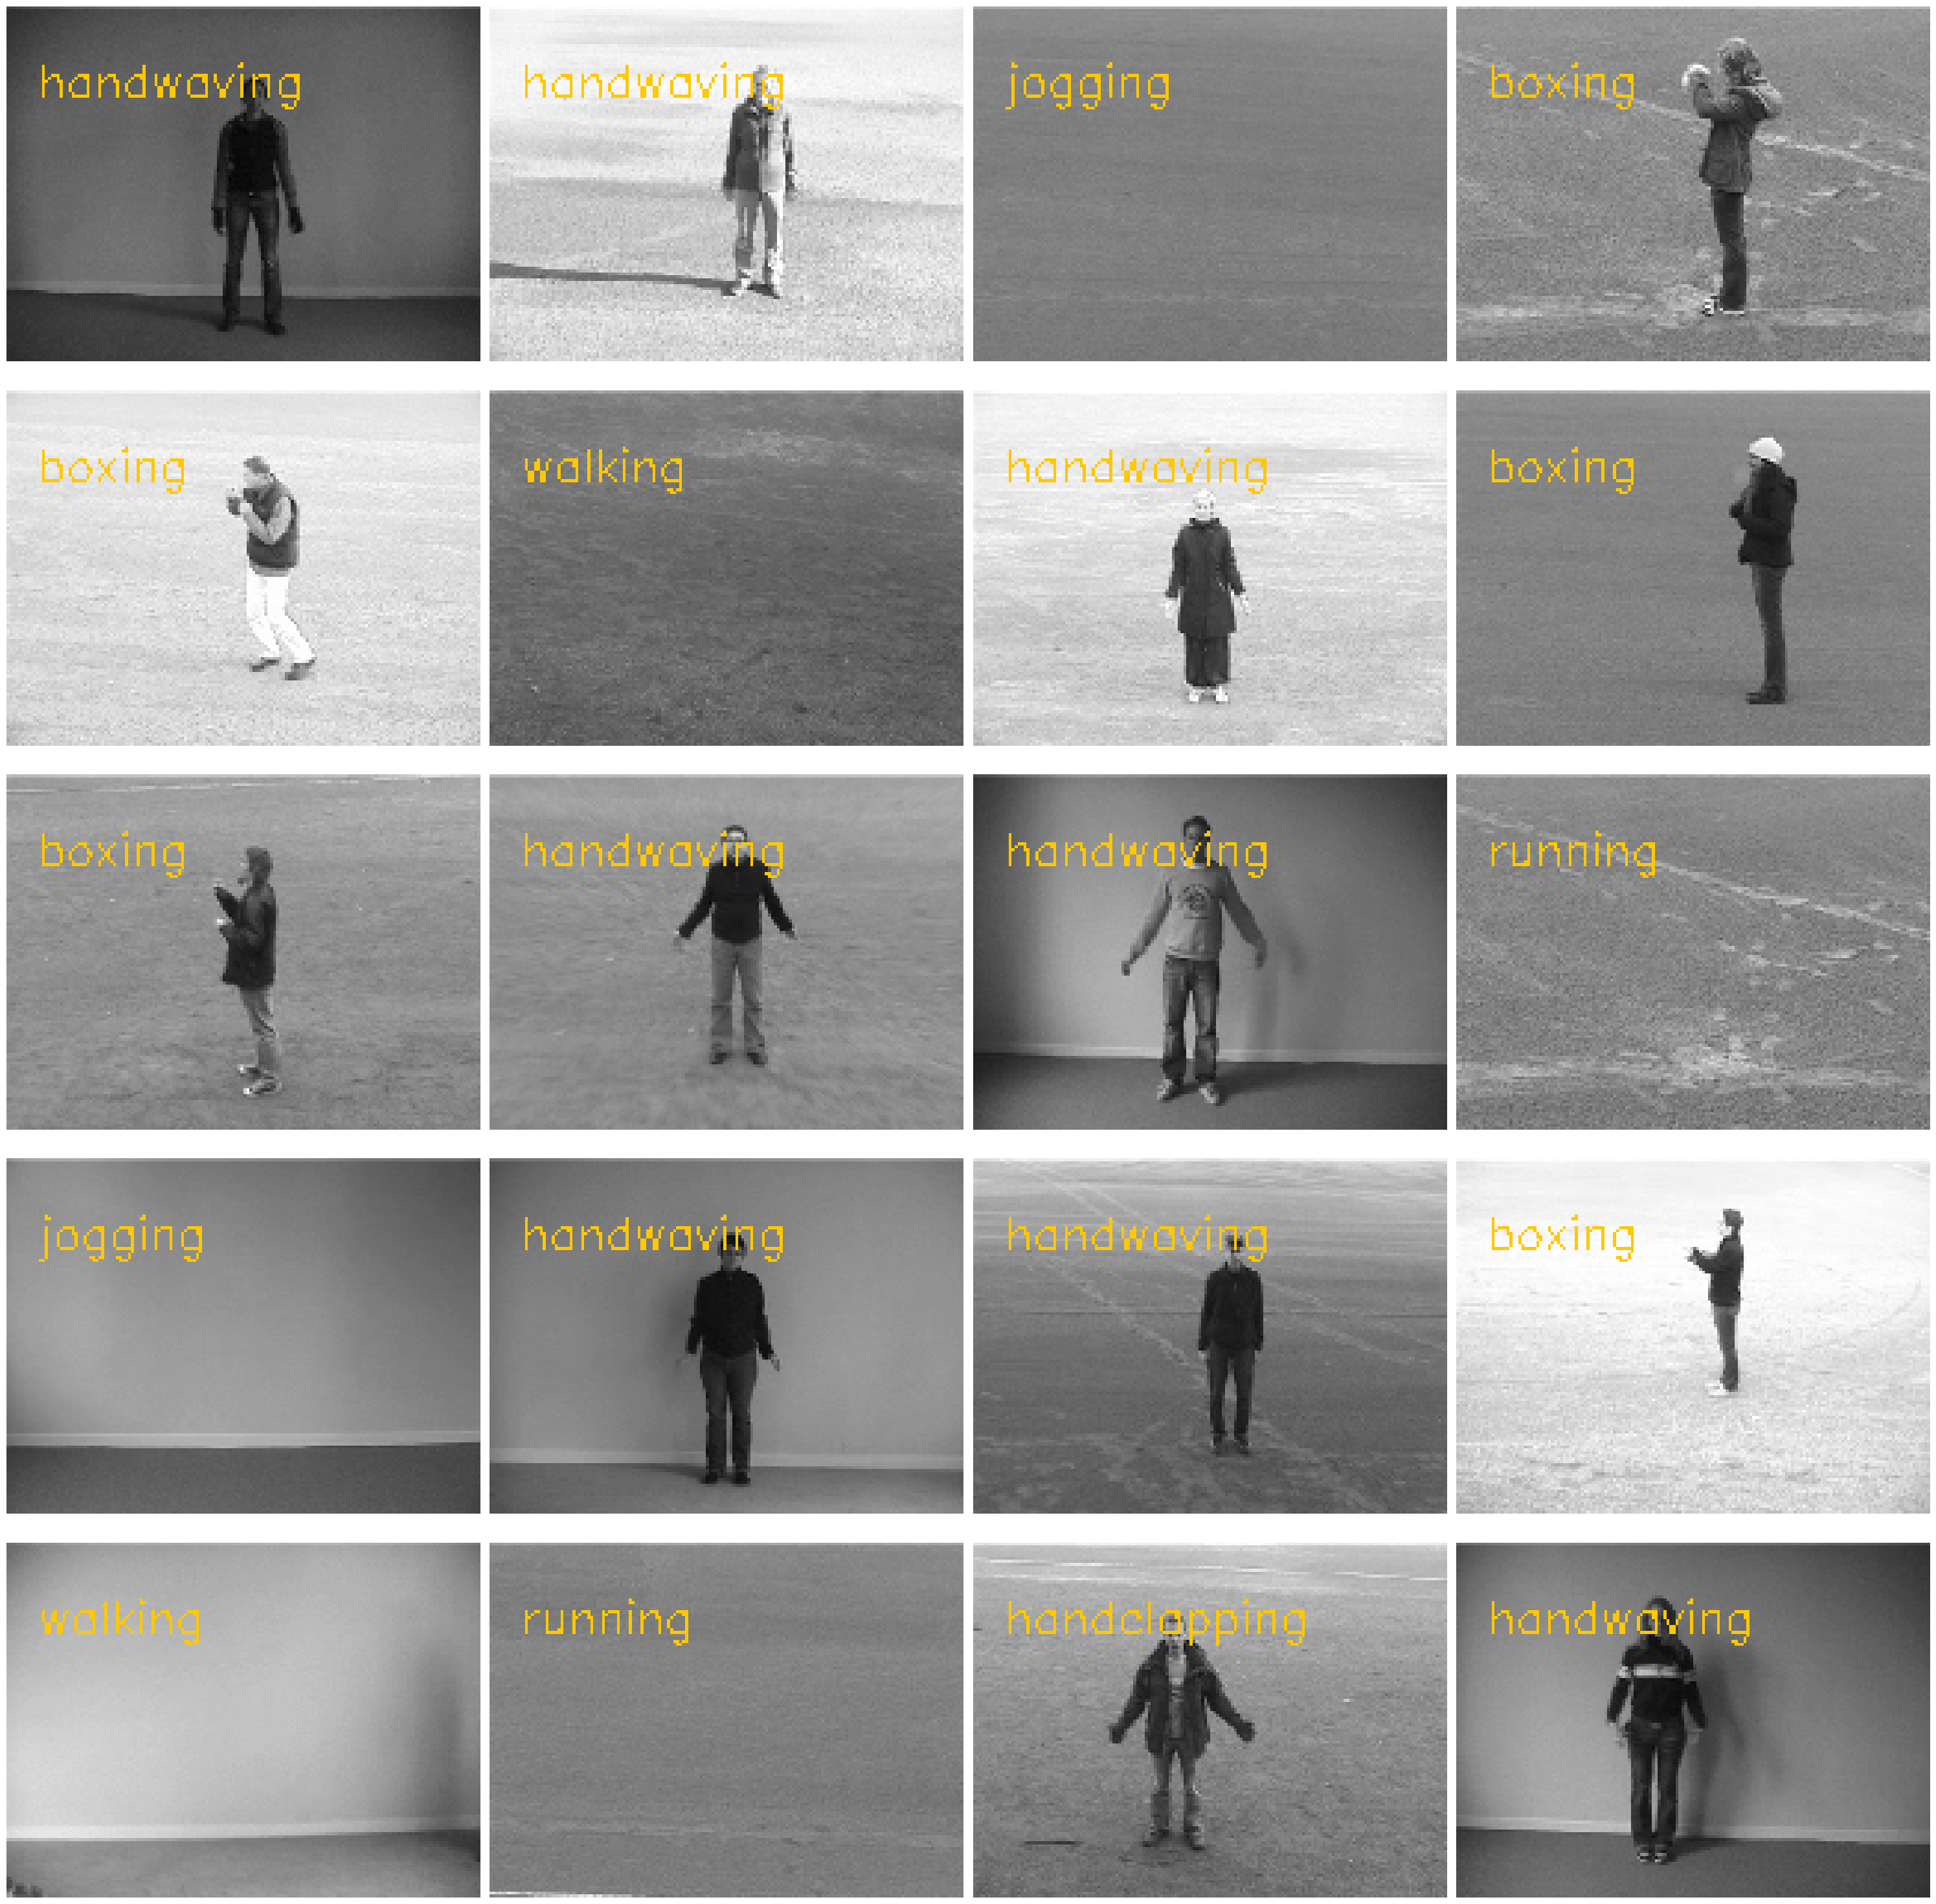

In [14]:
# Download Data
print("Checking for KTH dataset...")
data_path = download_data()

# Visualize the Data
visualize_data(data_path)# excluding the sequence.txt file

Seed set to: 0
Saving all results to: ./runs/run_20260518_154347
Partitioning dataset into ./kth_split...
Subject Splits -> Train: 16, Val: 4, Test: 5


[mpeg4 @ 0xa1b0e00] ac-tex damaged at 8 6
[mpeg4 @ 0xa1b0e00] Error at MB: 74


Partitioning complete!

Setting up model...
Using device: cuda
Starting Training Loop...

Epoch 1/30
---------------
Train Loss: 1.6539 | Acc: 30.76%
Validation Loss: 1.4377 | Acc: 53.69%

Epoch 2/30
---------------
Train Loss: 1.3704 | Acc: 59.13%
Validation Loss: 1.1532 | Acc: 61.97%

Epoch 3/30
---------------
Train Loss: 1.1112 | Acc: 77.18%
Validation Loss: 0.8602 | Acc: 83.89%

Epoch 4/30
---------------
Train Loss: 0.9022 | Acc: 81.01%
Validation Loss: 0.6117 | Acc: 84.25%

Epoch 5/30
---------------
Train Loss: 0.6878 | Acc: 90.59%
Validation Loss: 0.3800 | Acc: 93.92%

Epoch 6/30
---------------
Train Loss: 0.5995 | Acc: 88.74%
Validation Loss: 0.3267 | Acc: 91.72%

Epoch 7/30
---------------
Train Loss: 0.5238 | Acc: 89.58%
Validation Loss: 0.2226 | Acc: 96.60%

Epoch 8/30
---------------
Train Loss: 0.4392 | Acc: 91.96%
Validation Loss: 0.2335 | Acc: 91.95%

Epoch 9/30
---------------
Train Loss: 0.4214 | Acc: 91.25%
Validation Loss: 0.1608 | Acc: 95.95%

Epoch 10/30
-------

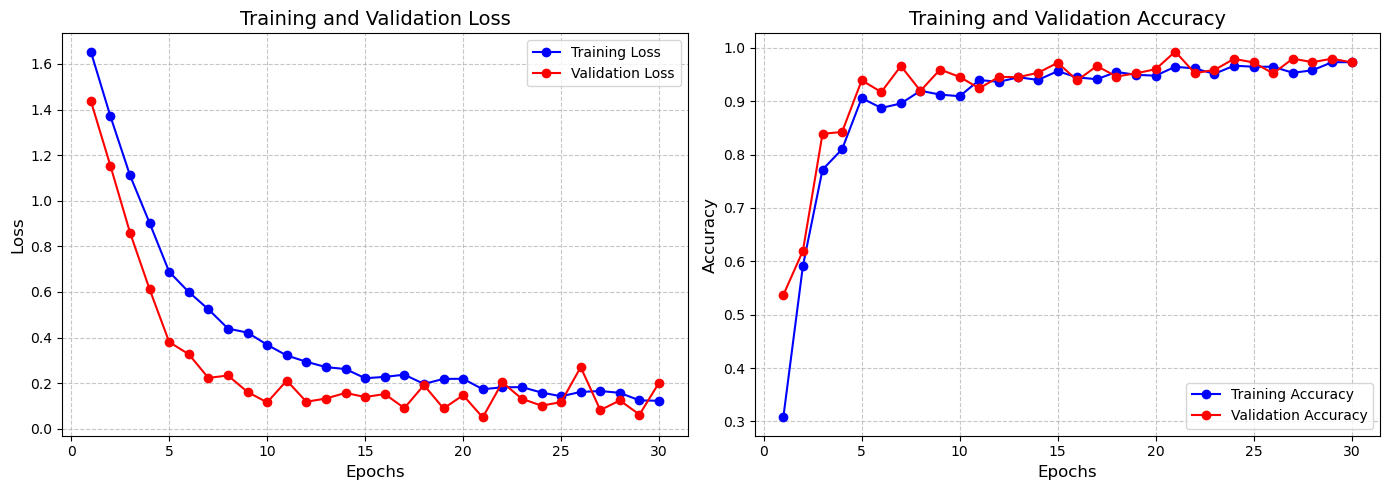


Model weights saved to ./runs/run_20260518_154347/best_s3d_model.pth

Running Final Evaluation on Test Set...

Evaluating model with TorchMetrics...
Overall Accuracy: 96.67%
Classification Report:
              precision    recall  f1-score   support

      boxing       1.00      1.00      1.00        43
handclapping       1.00      1.00      1.00        62
  handwaving       1.00      1.00      1.00        53
     jogging       0.79      1.00      0.88        38
     running       1.00      0.80      0.89        50
     walking       1.00      1.00      1.00        52

    accuracy                           0.97       298
   macro avg       0.97      0.97      0.96       298
weighted avg       0.97      0.97      0.97       298

Classification report saved to ./runs/run_20260518_154347/classification_report.txt


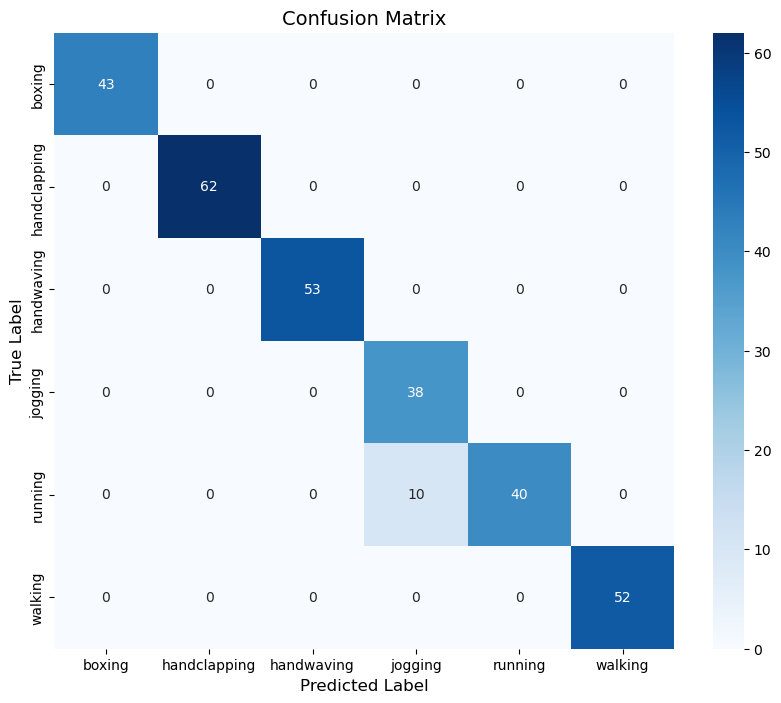

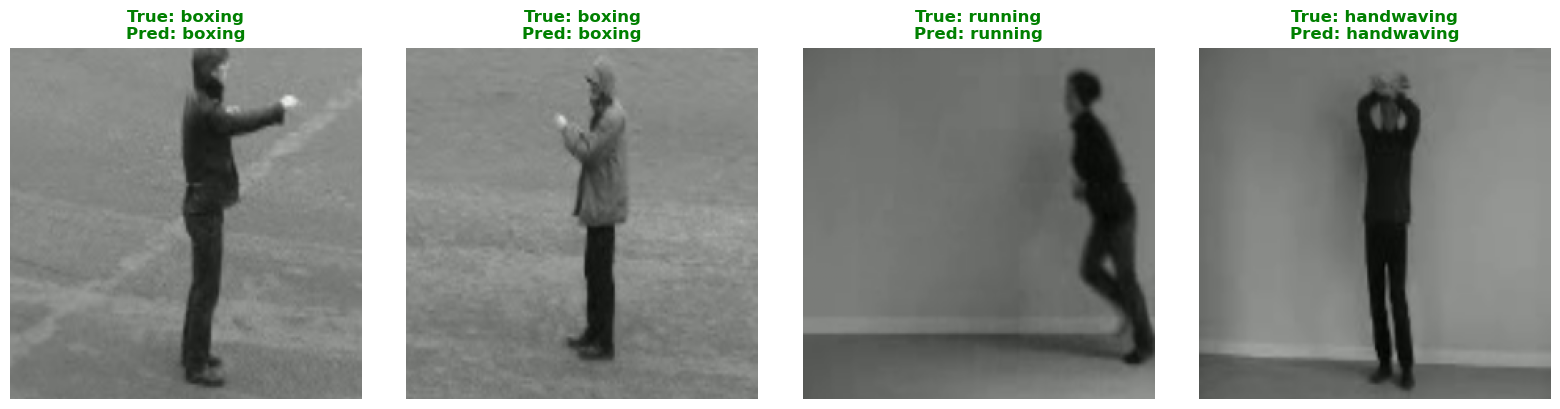

In [15]:
# Hyperparameters
SEED = 0
TEST_SPLIT = 0.2
VAL_SPLIT = 0.2
BATCH_SIZE = 8
NR_EPOCHS = 30
LEARNING_RATE = 1e-5
CLIP_LEN = 32

# Setting seed
set_seed(SEED)

# --- CREATE A RUN DIRECTORY ---
# Creates a folder like: ./runs/run_20231024_153022
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = f"./runs/run_{timestamp}"
os.makedirs(run_dir, exist_ok=True)
print(f"Saving all results to: {run_dir}")

# --- SAVE HYPERPARAMETERS ---
hyperparams = {
    "SEED": SEED,
    "TEST_SPLIT": TEST_SPLIT,
    "VAL_SPLIT": VAL_SPLIT,
    "BATCH_SIZE": BATCH_SIZE,
    "NR_EPOCHS": NR_EPOCHS,
    "LEARNING_RATE": LEARNING_RATE,
    "CLIP_LEN": CLIP_LEN,
    "MODEL": "S3D (Kinetics400 Pre-trained)"
}
with open(os.path.join(run_dir, "hyperparams.json"), "w") as f:
    json.dump(hyperparams, f, indent=4)


# --- DATA & MODEL SETUP ---

# Randomly Partitions Data (Creates ./kth_split if it doesn't exist)
split_dir = partition_kth_dataset(orig_dir=data_path, target_dir="./kth_split", test_split=TEST_SPLIT, val_split=VAL_SPLIT, seed = SEED)

# Setup Model
print("\nSetting up model...")
model, device = setup_model()

# Get the transforms
weights = S3D_Weights.KINETICS400_V1
preprocess = weights.transforms()

# Define paths for all three splits
train_dir = os.path.join(split_dir, "train")
val_dir = os.path.join(split_dir, "validation")
test_dir = os.path.join(split_dir, "test")

# Set up DataLoaders for Train and Validation (used during the training loop)
dataset_train = KTHVideoDataset(root=train_dir, epoch_size=600, transform=preprocess, clip_len=CLIP_LEN)
dataset_val = KTHVideoDataset(root=val_dir, epoch_size=150, transform=preprocess, clip_len=CLIP_LEN) # Smaller epoch size for val

# Pack them into a dictionary for the training function
dataloaders = {
    'train': DataLoader(dataset_train, batch_size=BATCH_SIZE, num_workers=0),
    'validation': DataLoader(dataset_val, batch_size=BATCH_SIZE, num_workers=0)
}

# Class labels specific to KTH
class_names = ['boxing', 'handclapping', 'handwaving', 'jogging', 'running', 'walking']


# --- TRAIN & PLOT ---
model, history = train_model(
    model=model, 
    dataloaders=dataloaders, 
    device=device, 
    class_names=class_names, 
    num_epochs=NR_EPOCHS, 
    learning_rate=LEARNING_RATE
)

# Plot and save the Learning Curves
plot_learning_curves(history, save_dir=run_dir)

# --- SAVE MODEL WEIGHTS ---
model_save_path = os.path.join(run_dir, "best_s3d_model.pth")
torch.save(model.state_dict(), model_save_path)
print(f"\nModel weights saved to {model_save_path}")

# --- EVALUATE & VISUALIZE ---
print("\nRunning Final Evaluation on Test Set...")

#Initialize Testing Datasets & Loaders
dataset_test = KTHVideoDataset(root=test_dir, epoch_size=300, transform=preprocess, clip_len=CLIP_LEN)
dataloader_test = DataLoader(dataset_test, batch_size=BATCH_SIZE, num_workers=0) 

#Evaluate the Model
evaluate_model(model, dataloader_test, device, class_names,save_dir=run_dir)

# Visualize Predictions
visualize_predictions(model, dataloader_test, device, class_names, save_dir=run_dir)
